In [1]:
import torch
import torch.nn as nn

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.data.dataset import random_split

VALIDATION_SPLIT = 0.2

BASE_BATCH = 256
BASE_EPOCH = 30
STOPPING_EPOCH = 10
STOPPING_TOL = 0.005

IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3
CLASSES = 10

UPDATE_MODELS = True

try:
    len(results_df)
except NameError:
    results_df = pd.DataFrame(columns=['Model', 'Train Loss', 'Val Loss', 'Train Acc', 'Val Acc', 'Test Acc'])

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA device found.", torch.cuda.is_available())
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print ("MPS device found.", torch.backends.mps.is_available())
else:
    device = torch.device("cpu")
    print ("MPS/GPU device not found.")

CUDA device found. True


# Basic Pytorch Model Tuning

## Datset

For this datset, we'll use something that is reasonably highly dimensional. 

In [3]:
#load cifar10

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Define the root directory where the dataset will be stored or is already located
# This path can be absolute or relative
data_root = './data/cifar10_data'  # Change this to your desired path

# Define transformations to apply to the images (e.g., resize, convert to Tensor)

transform = transforms.Compose([
    #transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),  # Resize images to the expected input size
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load the CIFAR10 dataset
train_dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,              # Set to True for training set, False for test set
    download=True,           # Automatically download if not found
    transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=False,             # Set to False for test set
    download=True,           # Automatically download if not found
    transform=transform
)

val_size = int(VALIDATION_SPLIT * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Use a DataLoader to efficiently load data in batches
train_loader = DataLoader(
    train_dataset,
    batch_size=BASE_BATCH,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BASE_BATCH,
    shuffle=False,
    num_workers=4
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BASE_BATCH,
    shuffle=False
)
classes = train_dataset.dataset.classes

print(f"Loaded {len(train_dataset)} images for the training set.")
print(f"Loaded {len(val_dataset)} images for the validation set.")
print(f"Loaded {len(test_dataset)} images for the test set.")
print("Native image size:", train_dataset.dataset.data.shape[1:])  # Original image size (32, 32, 3)
print("Classes:", classes)

100%|██████████| 170M/170M [00:04<00:00, 42.5MB/s] 


Loaded 40000 images for the training set.
Loaded 10000 images for the validation set.
Loaded 10000 images for the test set.
Native image size: (32, 32, 3)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Training Loop

This big loop will do most of the work for us, mainly it will:
<ul>
<li>Train the model. </li>
<li>Evaluate the model on the validation set. </li>
<li>Keep track of those scores. </li>
<li>Implement early stopping. </li>
<li>Perform final testing. </li>
<li>Return the results. </li>
</ul>

This loop is made to capture a bunch of information in addition to training the model. The results are compiled later for comparison. 

In [4]:
def fullTrainLoop(model, test_loader, val_loader, optimizer,
                  criterion, device, epochs=100, print_results=True, chart=True,
                  stopping_epochs=10, stopping_threshold=0.01, run_test=True):

    model.to(device)
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    best_val_accuracy = 0
    epochs_no_improve = 0
    
    # Train
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        with torch.enable_grad():
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                pred = outputs.argmax(dim=1)
                correct_train += (pred == labels).sum().item()
                total_train += labels.size(0)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                #print(f'Batch Loss: {loss.item():.4f}', end='\r')

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = correct_train / total_train
        train_accuracies.append(epoch_train_accuracy)
        train_losses.append(epoch_train_loss)
        #print(f'Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}')

        model.eval()
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                val_outputs = model(val_inputs)
                val_loss = criterion(val_outputs, val_labels)
                val_running_loss += val_loss.item() * val_inputs.size(0)
                val_preds = val_outputs.argmax(dim=1)
                correct_val += (val_preds == val_labels).sum().item()
                total_val += val_labels.size(0)

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        epoch_val_accuracy = correct_val / total_val
        val_accuracies.append(epoch_val_accuracy)

        if print_results:
            print(f'Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f} Train Acc: {epoch_train_accuracy:.4f}, Val Acc: {val_accuracies[-1]:.4f} Stopping Counter: {epochs_no_improve}/{stopping_epochs}')

        # Early stopping logic
        if epoch_val_accuracy > best_val_accuracy + stopping_threshold:
            best_val_accuracy = epoch_val_accuracy
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            if epochs_no_improve >= stopping_epochs:
                print(f'Early stopping at epoch {epoch+1} with best val accuracy: {best_val_accuracy:.4f}')
                break
            epochs_no_improve += 1

    if chart:
        chartResults(train_losses, val_losses, train_accuracies, val_accuracies)
    
    if run_test:
        test_accuracy, correct, total = test_model(model, test_loader, device)
        print(f'Test Accuracy: {test_accuracy:.4f} ({correct}/{total})')
            
    model.load_state_dict(torch.load('best_model.pth'))
    return train_losses, val_losses, train_accuracies, val_accuracies, test_accuracy

def chartResults(train_losses, val_losses, train_accuracies, val_accuracies):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.lineplot(x=range(1, len(train_losses) + 1), y=train_losses, ax=ax[0], label='Train Loss')
    sns.lineplot(x=range(1, len(val_losses) + 1), y=val_losses, ax=ax[0], label='Val Loss')
    ax[0].set_title('Loss Curves')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    # Accuracies
    sns.lineplot(x=range(1, len(train_accuracies) + 1), y=train_accuracies, ax=ax[1], label='Train Accuracy')
    sns.lineplot(x=range(1, len(val_accuracies) + 1), y=val_accuracies, ax=ax[1], label='Val Accuracy')
    ax[1].set_title('Accuracy Curves')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    plt.tight_layout()
    plt.show()

def test_model(model, test_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    test_accuracy = correct / total
    #print(f'Test Accuracy: {test_accuracy:.4f}')
    return test_accuracy, correct, total

def previewBatch(loader, classes, numberPrinted=12, rows=2, renormalize=True):
    dataiter = iter(loader)
    images, labels = next(dataiter)
    images = images[:numberPrinted]
    labels = labels[:numberPrinted]
    fig, axes = plt.subplots(rows, numberPrinted // rows, figsize=(15, 3))
    for i in range(numberPrinted):
        ax = axes[i // (numberPrinted // rows), i % (numberPrinted // rows)]
        if renormalize:
            img = images[i].permute(1, 2, 0) * 0.5 + 0.5  # Unnormalize
        else:
            img = images[i].permute(1, 2, 0)
        ax.imshow(img.cpu())
        ax.set_title(classes[labels[i]])
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    

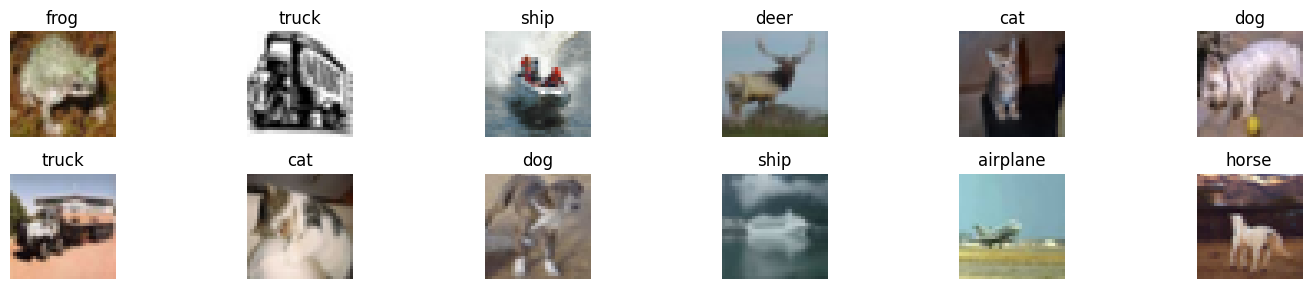

In [5]:
previewBatch(train_loader, classes)

In [6]:
def shouldTrain(train_flag, results_dataframe, model_name):
    models = results_dataframe.Model.values
    if not any(model_name == m for m in models):
        return True
    else:
        return train_flag

## Baseline Model

We will start with two baselines:
<ul>
<li>A simple fully conected model. </li>
<li>A CNN model. </li>
</ul>

For the subsequent tuning stages, we'll mainly update the fully connected parts of the CNN model - the convolutional layers will be sort of static feature constructors. 

<b>Note:</b> in the code below, the examples are a little more cluttered than normal because we are collecting all the stats. You can ignore that stuff. 

In [7]:
BASE_HIDDEN = 256

In [8]:
fc_baseline = nn.Sequential(
    nn.Flatten(),
    nn.Linear( IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, CLASSES),
)

fc_base_optimizer = torch.optim.Adam(fc_baseline.parameters())
fc_base_criterion = nn.CrossEntropyLoss()

Epoch 1/30, Train Loss: 1.6812, Val Loss: 1.5505 Train Acc: 0.4054, Val Acc: 0.4487 Stopping Counter: 0/10
Epoch 2/30, Train Loss: 1.4535, Val Loss: 1.4641 Train Acc: 0.4877, Val Acc: 0.4872 Stopping Counter: 0/10
Epoch 3/30, Train Loss: 1.3386, Val Loss: 1.4037 Train Acc: 0.5303, Val Acc: 0.5053 Stopping Counter: 0/10
Epoch 4/30, Train Loss: 1.2406, Val Loss: 1.4047 Train Acc: 0.5672, Val Acc: 0.5112 Stopping Counter: 0/10
Epoch 5/30, Train Loss: 1.1624, Val Loss: 1.3942 Train Acc: 0.5937, Val Acc: 0.5156 Stopping Counter: 0/10
Epoch 6/30, Train Loss: 1.0852, Val Loss: 1.3930 Train Acc: 0.6203, Val Acc: 0.5248 Stopping Counter: 1/10
Epoch 7/30, Train Loss: 1.0129, Val Loss: 1.4062 Train Acc: 0.6451, Val Acc: 0.5262 Stopping Counter: 0/10
Epoch 8/30, Train Loss: 0.9465, Val Loss: 1.4259 Train Acc: 0.6684, Val Acc: 0.5308 Stopping Counter: 1/10
Epoch 9/30, Train Loss: 0.8767, Val Loss: 1.4820 Train Acc: 0.6944, Val Acc: 0.5226 Stopping Counter: 0/10
Epoch 10/30, Train Loss: 0.8037, Val 

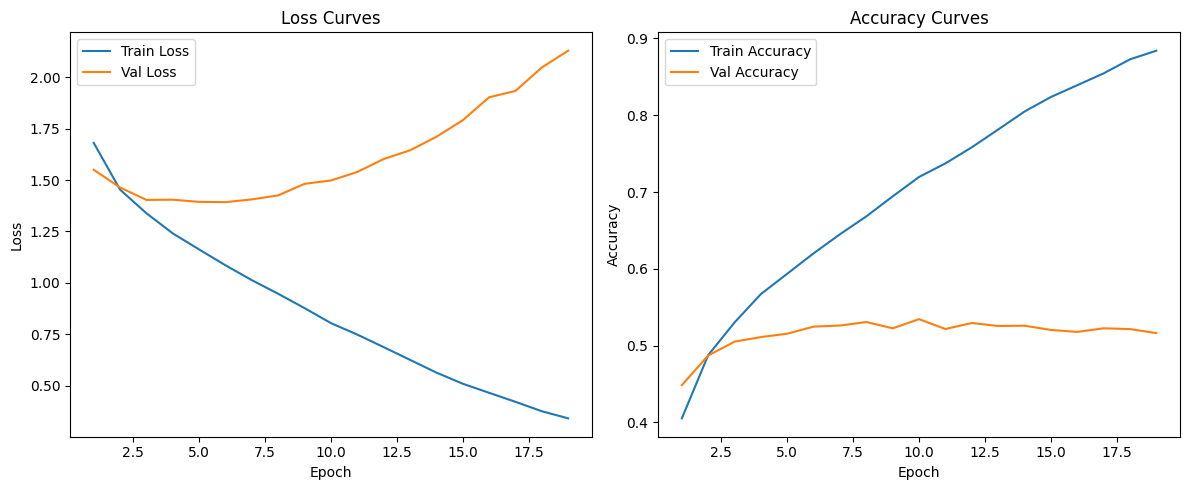

Test Accuracy: 0.9168 (36671/40000)


/tmp/ipykernel_1567/1499407524.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame({'Model': ['FC Baseline'],


In [9]:
if (shouldTrain(UPDATE_MODELS, results_df, 'FC Baseline')):
    fc_base_tl, fc_base_vl, fc_base_ta, fc_base_va, fc_base_test_acc = fullTrainLoop(fc_baseline, train_loader, val_loader, fc_base_optimizer,
                    fc_base_criterion, device, epochs=BASE_EPOCH, print_results=True, chart=True,
                    stopping_epochs=STOPPING_EPOCH, stopping_threshold=STOPPING_TOL, run_test=True)
    results_df = pd.concat([results_df, pd.DataFrame({'Model': ['FC Baseline'],
                                'Train Loss': [fc_base_tl[-1]], 'Val Loss': [fc_base_vl[-1]], 
                                'Train Acc': [fc_base_ta[-1]], 'Val Acc': [fc_base_va[-1]], 
                                'Test Acc': [fc_base_test_acc]})], ignore_index=True)

In [10]:
results_df.head()

,Model,Train Loss,Val Loss,Train Acc,Val Acc,Test Acc
0,FC Baseline,0.340122,2.130198,0.88405,0.5164,0.916775


### Baseline CNN

We can also set a baseline with a simple CNN architecture, which should perform better than the fully connected model on image data.

<b>Note:</b> There is some math needed to calculate the correct sizes depending on the setup of the convolutional layers.

In [11]:
KERNEL_NUM = 32
KERNEL_SIZE = 3
STRIDE = 1
PADDING = 1

FLAT_DIM = (IMG_HEIGHT // 4) * (IMG_WIDTH // 4) * KERNEL_NUM * 2

class CNN_base(nn.Module):
    def __init__(self):
        super(CNN_base, self).__init__()
        self.cnn_layers = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, KERNEL_NUM, KERNEL_SIZE, STRIDE, PADDING),
            nn.ReLU(),
            nn.MaxPool2d( (2,2)),
            nn.Conv2d(KERNEL_NUM, KERNEL_NUM * 2, KERNEL_SIZE, STRIDE, PADDING),
            nn.ReLU(),
            nn.MaxPool2d( (2,2))
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(FLAT_DIM, BASE_HIDDEN)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(BASE_HIDDEN, BASE_HIDDEN)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(BASE_HIDDEN, CLASSES)

    def forward(self, x):
        x = self.cnn_layers(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

Epoch 1/30, Train Loss: 1.5969, Val Loss: 1.3224 Train Acc: 0.4192, Val Acc: 0.5154 Stopping Counter: 0/10
Epoch 2/30, Train Loss: 1.2090, Val Loss: 1.1352 Train Acc: 0.5679, Val Acc: 0.5905 Stopping Counter: 0/10
Epoch 3/30, Train Loss: 1.0193, Val Loss: 1.0092 Train Acc: 0.6353, Val Acc: 0.6446 Stopping Counter: 0/10
Epoch 4/30, Train Loss: 0.8885, Val Loss: 0.9491 Train Acc: 0.6844, Val Acc: 0.6619 Stopping Counter: 0/10
Epoch 5/30, Train Loss: 0.7772, Val Loss: 0.9457 Train Acc: 0.7247, Val Acc: 0.6702 Stopping Counter: 0/10
Epoch 6/30, Train Loss: 0.6818, Val Loss: 0.8675 Train Acc: 0.7598, Val Acc: 0.7020 Stopping Counter: 0/10
Epoch 7/30, Train Loss: 0.5870, Val Loss: 0.8592 Train Acc: 0.7927, Val Acc: 0.7040 Stopping Counter: 0/10
Epoch 8/30, Train Loss: 0.4913, Val Loss: 0.9251 Train Acc: 0.8271, Val Acc: 0.6923 Stopping Counter: 1/10
Epoch 9/30, Train Loss: 0.3991, Val Loss: 0.9498 Train Acc: 0.8601, Val Acc: 0.7038 Stopping Counter: 2/10
Epoch 10/30, Train Loss: 0.3217, Val 

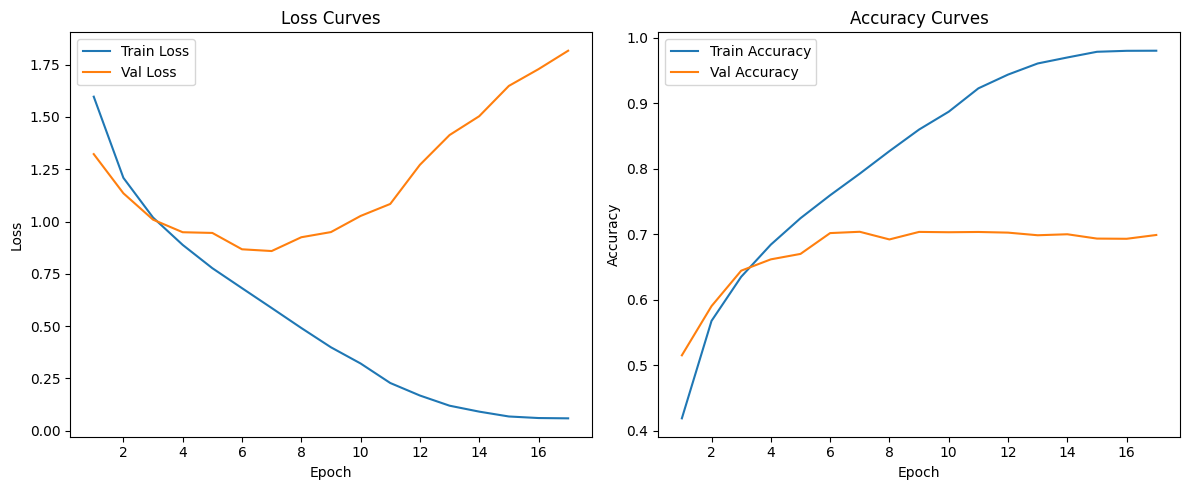

Test Accuracy: 0.9821 (39284/40000)


In [12]:
cnn_base = CNN_base()
cnn_base_optimizer = torch.optim.Adam(cnn_base.parameters())
cnn_base_criterion = nn.CrossEntropyLoss()

if (shouldTrain(UPDATE_MODELS, results_df, 'CNN Baseline')):
    cnn_base_tl, cnn_base_vl, cnn_base_ta, cnn_base_va, cnn_base_test_acc = fullTrainLoop(cnn_base, train_loader, val_loader, cnn_base_optimizer,
                    cnn_base_criterion, device, epochs=BASE_EPOCH, print_results=True, chart=True,
                    stopping_epochs=STOPPING_EPOCH, stopping_threshold=STOPPING_TOL, run_test=True)
    results_df = pd.concat([results_df, pd.DataFrame({'Model': ['CNN Baseline'],
                                    'Train Loss': [cnn_base_tl[-1]], 'Val Loss': [cnn_base_vl[-1]], 
                                    'Train Acc': [cnn_base_ta[-1]], 'Val Acc': [cnn_base_va[-1]], 
                                    'Test Acc': [cnn_base_test_acc]})], ignore_index=True)

In [13]:
results_df.head()

,Model,Train Loss,Val Loss,Train Acc,Val Acc,Test Acc
0,FC Baseline,0.340122,2.130198,0.884050,0.5164,0.916775
1,CNN Baseline,0.059570,1.816624,0.980425,0.6991,0.982100


## Prequel - Saving and Loading Models

Training neural networks takes a long time, and may be done on a different system or more than one system. We can save our weights and the model, then reload them later, so we can keep reusing the same model and weights without having to retrain it every time. In real life examples, this is how we can share models with other people, or use pretrained models that have been trained on large datasets by other people. The weights are the main thing that changes in training, so we can save those and reload them into the same model architecture later.

This example saves the weights, which can then be reloaded into an "empty" model that has the same architecture. You can also save the entire model, which includes the architecture and the weights, but this requires more data from the model object to be saved, which can be less likely to work smoothly across different systems and versions of libraries. Saving just the weights just requires the saving of a bunch of float values, which can just be restored into their spots. 

In [14]:
torch.save(fc_baseline.state_dict(), 'fc_baseline_weights.pth')
# Create a new instance of the model with the same architecture
fc_baseline_loaded = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, CLASSES),
)

# Load the weights
fc_baseline_loaded.load_state_dict(torch.load('fc_baseline_weights.pth'))

<All keys matched successfully>

### Saving Special Models

We can save a model like this whenever we please, and recreate it to continue training or to use it to make predictions. We can also write this code into our training loop, to save the model at intermittent steps. This could be useful if you needed to train in parts - e.g. you have a limited time on a GPU (like colab), so you train for a while, save the model, then reload it later to continue training. It is also very useful for early stopping, or terminating training when the model is performing well, before it begins to overfit. Early stopping allows us to train models easier, and our weights will be ready to use when we want to use them.

## Training Epochs

The first tuning method is a free one, the number of epochs to train for. This is a version of regularization, it stops the model from training when it starts to get overtrained. It is also very convenient - we can set a model to train and trust that it'll stop if things stop improving. In code, this is really just a few if statements combined with commands to save and load the model parameters for the best model. 

### Early Stopping Setup

There are two things to configure with early stopping - the number of epochs we wait to see an improvement, and the threshold for how big that improvement must be to count. We want to allow some leeway for the model to stall or get worse a little bit to allow it to do things like get out of local minima. On the other hand, we don't want a model to get better by .000001% each epoch for a week of training. 

Early stopping is one of the best things to use when training neural networks, since it can basically allow us to always use the optimal number of epochs without having to do any tuning at all. The implementation in the training loop is pretty simple, we just need to check if whatever criteria we've set has been met, and if so, stop the training and load the best model parameters. Normally, we need to consider:
<ul>
<li> How many epochs is the model allowed to go without improving before we stop? (Patience) </li>
<li> How much does the model need to improve to count as an improvement? </li>
</ul>

We normally also want to save the best model parameters during training, so that we can load them back in when we stop. So, ultimately we'll need to have the following parts, in some configuration:
<ul>
<li> Early stopping settings - how many epochs to wait, the threshold for improvement. </li>
<li> A variable to keep track of the best score. </li>
<li> A variable to keep track of how many epochs it's been since the last improvement. </li>
<li> Something to check each epoch to see if the model has improved, and if so, save the model parameters and reset the counter. </li>
<li> Something to check each epoch to see if the model has gone too long without improving, and if so, stop the training and load the best model parameters. </li>
</ul>

This is pretty simple, any process that "saves the best" and cuts off training after a certain time will do the job. 

In [15]:
print("Early Stopping Epochs:", STOPPING_EPOCH)
print("Early Stopping Threshold:", STOPPING_TOL)

Early Stopping Epochs: 10
Early Stopping Threshold: 0.005


## Model Size

The most obvious thing we can adjust is the capacity of the model, both in terms of the width of layers and the number of layers, or the depth. 

Both of these adjustments will increase the number of parameters in the model, and thus the capacity of the model to learn complex relationships. However, they will also increase the risk of overfitting, and the time it takes to train the model.

### Width vs Depth

While both of these adjustments will increase the capacity of the model, they do so in different ways, and which one is better can depend on the specific problem and dataset.

In practice, the true answer comes down to results, we need to test and see which is better. Many common problems such as image and text classification have been found to be better solved with deeper models, but this is not a hard and fast rule. Although, no one talks about "wide learning". 

In [ ]:
fc_wide = nn.Sequential(
    nn.Flatten(),
    nn.Linear( IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS, BASE_HIDDEN * 3),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN * 3, BASE_HIDDEN * 2),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN * 2, CLASSES),

)
fc_deep = nn.Sequential(
    nn.Flatten(),
    nn.Linear( IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, CLASSES)
)

fc_wide_optimizer = torch.optim.Adam(fc_wide.parameters())
fc_wide_criterion = nn.CrossEntropyLoss()
fc_deep_optimizer = torch.optim.Adam(fc_deep.parameters())
fc_deep_criterion = nn.CrossEntropyLoss()

In [17]:
if (shouldTrain(UPDATE_MODELS, results_df, 'FC Wide')):
    fc_wide_tl, fc_wide_vl, fc_wide_ta, fc_wide_va, fc_wide_test_acc = fullTrainLoop(fc_wide, train_loader, val_loader, fc_wide_optimizer,
                    fc_wide_criterion, device, epochs=BASE_EPOCH, print_results=True, chart=True,
                    stopping_epochs=STOPPING_EPOCH, stopping_threshold=STOPPING_TOL, run_test=True)
    results_df = pd.concat([results_df, pd.DataFrame({'Model': ['FC Wide'], 
                                'Train Loss': [fc_wide_tl[-1]], 'Val Loss': [fc_wide_vl[-1]], 
                                'Train Acc': [fc_wide_ta[-1]], 'Val Acc': [fc_wide_va[-1]], 
                                'Test Acc': [fc_wide_test_acc]})], ignore_index=True)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (256x768 and 512x512)

In [ ]:
results_df.head()

,Model,Train Loss,Val Loss,Train Acc,Val Acc,Test Acc
0,FC Baseline,0.331251,2.142015,0.888825,0.5226,0.5184
1,CNN Baseline,0.045649,1.789014,0.986050,0.7041,0.6964


Epoch 1/30, Train Loss: 1.7842, Val Loss: 1.6518 Train Acc: 0.3518, Val Acc: 0.4166 Stopping Counter: 0/10
Epoch 2/30, Train Loss: 1.5297, Val Loss: 1.4915 Train Acc: 0.4556, Val Acc: 0.4728 Stopping Counter: 0/10
Epoch 3/30, Train Loss: 1.4058, Val Loss: 1.4480 Train Acc: 0.5039, Val Acc: 0.4942 Stopping Counter: 0/10
Epoch 4/30, Train Loss: 1.2972, Val Loss: 1.3996 Train Acc: 0.5401, Val Acc: 0.5073 Stopping Counter: 0/10
Epoch 5/30, Train Loss: 1.2128, Val Loss: 1.4090 Train Acc: 0.5719, Val Acc: 0.5044 Stopping Counter: 0/10
Epoch 6/30, Train Loss: 1.1271, Val Loss: 1.3739 Train Acc: 0.5959, Val Acc: 0.5256 Stopping Counter: 1/10
Epoch 7/30, Train Loss: 1.0559, Val Loss: 1.3773 Train Acc: 0.6272, Val Acc: 0.5275 Stopping Counter: 0/10
Epoch 8/30, Train Loss: 0.9751, Val Loss: 1.4079 Train Acc: 0.6542, Val Acc: 0.5185 Stopping Counter: 1/10
Epoch 9/30, Train Loss: 0.9027, Val Loss: 1.4802 Train Acc: 0.6795, Val Acc: 0.5258 Stopping Counter: 2/10
Epoch 10/30, Train Loss: 0.8361, Val 

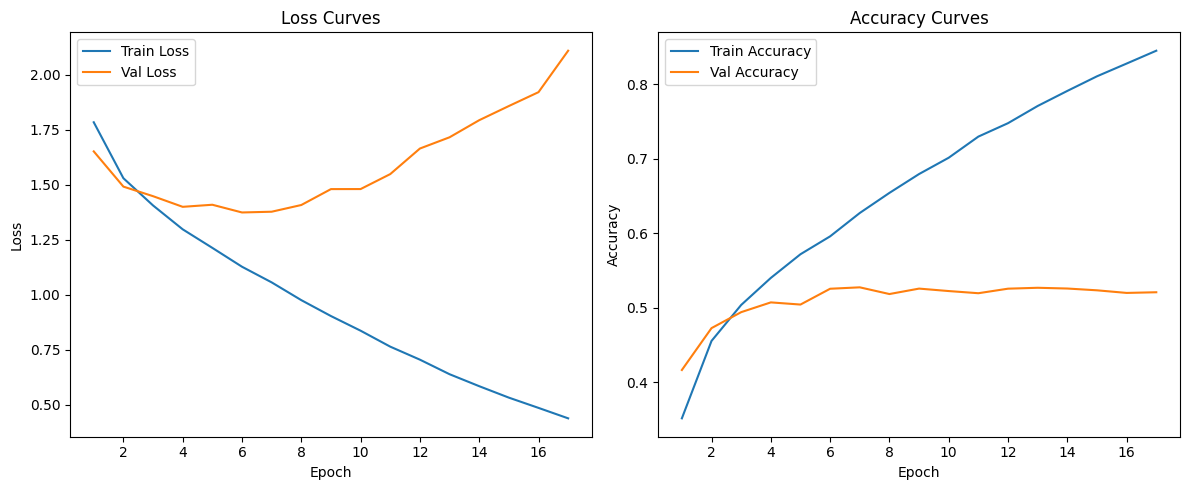

Test Accuracy: 0.5181 (5181/10000)


In [ ]:
if (shouldTrain(UPDATE_MODELS, results_df, 'FC Deep')):
    fc_deep_tl, fc_deep_vl, fc_deep_ta, fc_deep_va, fc_deep_test_acc = fullTrainLoop(fc_deep, train_loader, val_loader, fc_deep_optimizer,
                    fc_deep_criterion, device, epochs=BASE_EPOCH, print_results=True, chart=True,
                    stopping_epochs=STOPPING_EPOCH, stopping_threshold=STOPPING_TOL, run_test=True)
    results_df = pd.concat([results_df, pd.DataFrame({'Model': ['FC Deep'], 
                                    'Train Loss': [fc_deep_tl[-1]], 'Val Loss': [fc_deep_vl[-1]], 
                                    'Train Acc': [fc_deep_ta[-1]], 'Val Acc': [fc_deep_va[-1]], 
                                    'Test Acc': [fc_deep_test_acc]})], ignore_index=True)

In [ ]:
results_df.head()

,Model,Train Loss,Val Loss,Train Acc,Val Acc,Test Acc
0,FC Baseline,0.331251,2.142015,0.888825,0.5226,0.5184
1,CNN Baseline,0.045649,1.789014,0.986050,0.7041,0.6964
2,FC Deep,0.437455,2.109700,0.844925,0.5209,0.5181


## Regularization

Regularization is one of the most important, and easiest to utilize, tuning tools available. In pytorch, there are two main types of regularization that are commonly used - weight decay and dropout.

### Weight Decay

Weight decay is a regularization technique that adds a penalty to the loss function based on the magnitude of the weights, a technique you may recognize as "regularization". The implementation of weight decay in pytorch is actually a bit more complex than the simple L2 regularization that it is often equated with, but the basic idea is the same - it encourages the model to learn smaller weights, which can help prevent overfitting.

In the example below, we also set the parameter `decoupled_weight_decay=True`, which changes the way the weight decay is applied. With decoupled weight decay, the weight decay is applied directly to the weights after the optimization step, rather than being included in the loss function. This is not super critical for our purposes, but it can sometimes improve performance. Alternative, we can use AdamW, which is a variant of Adam that includes decoupled weight decay by default.

### Dropout

Dropout is a regularization technique that randomly sets a fraction of the input units to 0 at each update during training time. This process is somewhat analogous to the bootstrapping of datasets in a forest. Each epoch, a slightly different part of the model is deactivated, which forces the model to learn without relying on any portion. Training neural networks is very expensive, so it isn't really practical to train 100 networks in parallel as we would with a forest. This provides a similar effect, the model can't rely super heavily on any one part, since that part might be dropped out in the next epoch.

Remember, each layer is basically a big set of linear regression equations, and the impact any one x has on the output is determined by the weight, or coefficient/slope, of that x. If a couple of xs have very high weights, the model is relying heavily on those xs to make predictions in that layer, and the other xs may be drowned out in thier influence. By randomly dropping out some of the xs, we force the model to predict without these parts sometimes, which forces it to learn from other parts of the data, making it more robust and less likely to overfit.

![Dropout](images/dropout.png "Dropout" )

<b>Note:</b> Dropout is only applied during training, the model.eval() or model.train() commands will turn it on and off. 

In [ ]:
BASE_DROPOUT = 0.4

fc_dropout = nn.Sequential(
    nn.Flatten(),
    nn.Linear( IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS, BASE_HIDDEN),
    nn.ReLU(),
    nn.Dropout(BASE_DROPOUT),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.ReLU(),
    nn.Dropout(BASE_DROPOUT),
    nn.Linear(BASE_HIDDEN, CLASSES)
)
fc_dropout_optimizer = torch.optim.Adam(fc_dropout.parameters())
fc_dropout_criterion = nn.CrossEntropyLoss()

In [ ]:
if (shouldTrain(UPDATE_MODELS, results_df, 'FC Dropout')):
    fc_drop_tl, fc_drop_vl, fc_drop_ta, fc_drop_va, fc_drop_test_acc = fullTrainLoop(fc_dropout, train_loader, val_loader, 
                        fc_dropout_optimizer, fc_dropout_criterion, device, epochs=BASE_EPOCH, print_results=True, chart=True,
                        stopping_epochs=STOPPING_EPOCH, stopping_threshold=STOPPING_TOL, run_test=True)
    results_df = pd.concat([results_df, pd.DataFrame({'Model': ['FC Dropout'],
                                    'Train Loss': [fc_drop_tl[-1]], 'Val Loss': [fc_drop_vl[-1]], 
                                    'Train Acc': [fc_drop_ta[-1]], 'Val Acc': [fc_drop_va[-1]], 
                                    'Test Acc': [fc_drop_test_acc]})], ignore_index=True)

Epoch 1/30, Train Loss: 1.8258, Val Loss: 1.6185 Train Acc: 0.3462, Val Acc: 0.4351 Stopping Counter: 0/10
Epoch 2/30, Train Loss: 1.6547, Val Loss: 1.5538 Train Acc: 0.4146, Val Acc: 0.4620 Stopping Counter: 0/10
Epoch 3/30, Train Loss: 1.5880, Val Loss: 1.4877 Train Acc: 0.4366, Val Acc: 0.4811 Stopping Counter: 0/10
Epoch 4/30, Train Loss: 1.5390, Val Loss: 1.4613 Train Acc: 0.4539, Val Acc: 0.4916 Stopping Counter: 0/10
Epoch 5/30, Train Loss: 1.5020, Val Loss: 1.4328 Train Acc: 0.4691, Val Acc: 0.4933 Stopping Counter: 0/10
Epoch 6/30, Train Loss: 1.4734, Val Loss: 1.4130 Train Acc: 0.4829, Val Acc: 0.5081 Stopping Counter: 1/10
Epoch 7/30, Train Loss: 1.4468, Val Loss: 1.4015 Train Acc: 0.4861, Val Acc: 0.5052 Stopping Counter: 0/10
Epoch 8/30, Train Loss: 1.4297, Val Loss: 1.4050 Train Acc: 0.4914, Val Acc: 0.5037 Stopping Counter: 1/10
Epoch 9/30, Train Loss: 1.4018, Val Loss: 1.3898 Train Acc: 0.5063, Val Acc: 0.5169 Stopping Counter: 2/10
Epoch 10/30, Train Loss: 1.3802, Val 

KeyboardInterrupt: 

In [ ]:
results_df.head()

,Model,Train Loss,Val Loss,Train Acc,Val Acc,Test Acc
0,FC Baseline,0.805878,1.499681,0.718675,0.5264,0.5348
1,CNN Baseline,0.325204,0.956565,0.887125,0.7119,0.7135
2,FC Wide,0.639907,1.605606,0.775650,0.5275,0.5274
3,FC Deep,0.845638,1.501356,0.698000,0.5318,0.5344
4,FC Dropout,1.376967,1.394138,0.511825,0.5086,0.5252


In [ ]:
BASE_WEIGHT_DECAY = 1e-3

fc_weight_decay = nn.Sequential(
    nn.Flatten(),
    nn.Linear( IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, CLASSES)
)
fc_weight_decay_optimizer = torch.optim.Adam(fc_weight_decay.parameters(), weight_decay=BASE_WEIGHT_DECAY, decoupled_weight_decay=True)
fc_weight_decay_criterion = nn.CrossEntropyLoss()

Epoch 1/10, Train Loss: 1.6847, Val Loss: 1.5625 Train Acc: 0.4024, Val Acc: 0.4473 Stopping Counter: 0/10
Epoch 2/10, Train Loss: 1.4479, Val Loss: 1.4905 Train Acc: 0.4891, Val Acc: 0.4769 Stopping Counter: 0/10
Epoch 3/10, Train Loss: 1.3289, Val Loss: 1.4390 Train Acc: 0.5351, Val Acc: 0.4929 Stopping Counter: 0/10
Epoch 4/10, Train Loss: 1.2323, Val Loss: 1.4203 Train Acc: 0.5683, Val Acc: 0.5036 Stopping Counter: 0/10
Epoch 5/10, Train Loss: 1.1582, Val Loss: 1.3903 Train Acc: 0.5926, Val Acc: 0.5150 Stopping Counter: 0/10
Epoch 6/10, Train Loss: 1.0773, Val Loss: 1.4088 Train Acc: 0.6224, Val Acc: 0.5153 Stopping Counter: 0/10
Epoch 7/10, Train Loss: 1.0006, Val Loss: 1.4307 Train Acc: 0.6489, Val Acc: 0.5182 Stopping Counter: 1/10
Epoch 8/10, Train Loss: 0.9295, Val Loss: 1.4186 Train Acc: 0.6737, Val Acc: 0.5280 Stopping Counter: 2/10
Epoch 9/10, Train Loss: 0.8659, Val Loss: 1.4649 Train Acc: 0.6965, Val Acc: 0.5225 Stopping Counter: 0/10
Epoch 10/10, Train Loss: 0.8030, Val 

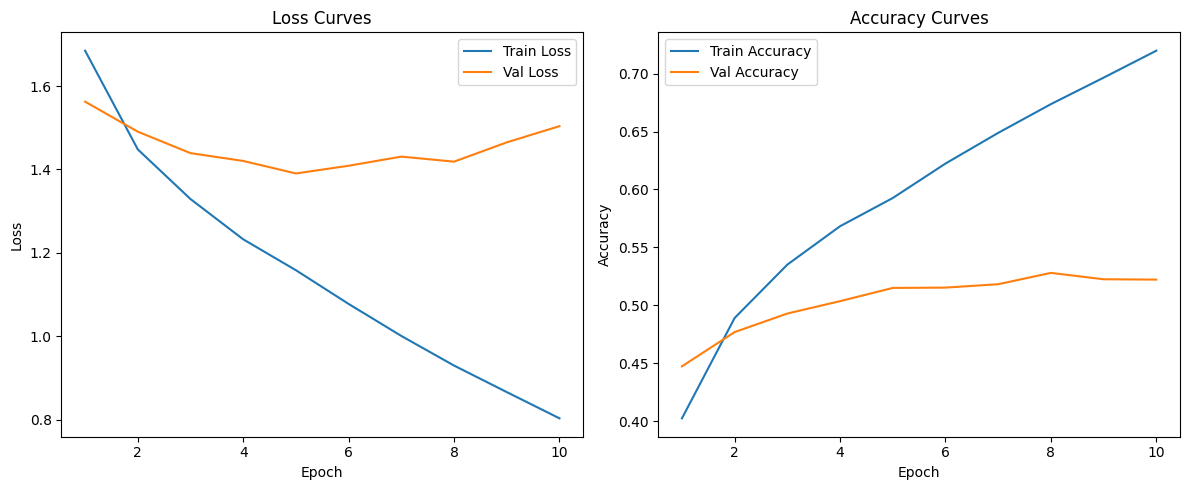

Test Accuracy: 0.5317 (5317/10000)


In [ ]:
if (shouldTrain(UPDATE_MODELS, results_df, 'FC L2 Reg')):
    fc_wd_tl, fc_wd_vl, fc_wd_ta, fc_wd_va, fc_wd_test_acc = fullTrainLoop(fc_weight_decay, 
                        train_loader, val_loader, fc_weight_decay_optimizer, fc_weight_decay_criterion, device, 
                        epochs=BASE_EPOCH, print_results=True, chart=True,
                        stopping_epochs=STOPPING_EPOCH, stopping_threshold=STOPPING_TOL, run_test=True)
    results_df = pd.concat([results_df, pd.DataFrame({'Model': ['FC L2 Reg'],
                                    'Train Loss': [fc_wd_tl[-1]], 'Val Loss': [fc_wd_vl[-1]], 
                                    'Train Acc': [fc_wd_ta[-1]], 'Val Acc': [fc_wd_va[-1]], 
                                    'Test Acc': [fc_wd_test_acc]})], ignore_index=True)

In [ ]:
results_df.head()

,Model,Train Loss,Val Loss,Train Acc,Val Acc,Test Acc
0,FC Baseline,0.805878,1.499681,0.718675,0.5264,0.5348
1,CNN Baseline,0.325204,0.956565,0.887125,0.7119,0.7135
2,FC Wide,0.639907,1.605606,0.775650,0.5275,0.5274
3,FC Deep,0.845638,1.501356,0.698000,0.5318,0.5344
4,FC Dropout,1.376967,1.394138,0.511825,0.5086,0.5252


### Batch Normalization

Batch normalization is a technique that normalizes the inputs of each layer to have a mean of 0 and a standard deviation of 1. This can help stabilize and accelerate the training process, and can also have a regularizing effect.

If weights drift very high or very low, the model can get into a state where it is very hard to learn, because the gradients can become very small or very large. If we look at the input range of the activation functions, we can see this in the chart - changes in the input can have very little effect on the output, unlike near the center of the activation function, where changes in the input have a much larger effect on the output. By normalizing the inputs to each layer, we basically recenter everything around the part of the activation function where it is most responsive, which can help the model learn more effectively.

In pytorch, batch normalization is implemented as a layer that can be added to the model. Normally, the batch normalization layer is added between the "working" layer (like a convolutional or fully connected layer) and the activation function. It has learnable parameters that allow it to scale and shift the normalized output, which can help the model learn more complex relationships.

![Batch Normalization](images/batch_norm_example.webp "Batch Normalization" )

In [ ]:
fc_batch_norm = nn.Sequential(
    nn.Flatten(),
    nn.Linear( IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS, BASE_HIDDEN),
    nn.BatchNorm1d(BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.BatchNorm1d(BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, CLASSES)
)
fc_batch_norm_optimizer = torch.optim.Adam(fc_batch_norm.parameters())
fc_batch_norm_criterion = nn.CrossEntropyLoss()

Epoch 1/10, Train Loss: 1.6324, Val Loss: 1.5304 Train Acc: 0.4195, Val Acc: 0.4476 Stopping Counter: 0/10
Epoch 2/10, Train Loss: 1.3967, Val Loss: 1.4252 Train Acc: 0.5037, Val Acc: 0.4918 Stopping Counter: 0/10
Epoch 3/10, Train Loss: 1.2848, Val Loss: 1.3821 Train Acc: 0.5436, Val Acc: 0.5025 Stopping Counter: 0/10
Epoch 4/10, Train Loss: 1.1951, Val Loss: 1.3743 Train Acc: 0.5782, Val Acc: 0.5139 Stopping Counter: 0/10
Epoch 5/10, Train Loss: 1.1189, Val Loss: 1.3517 Train Acc: 0.6051, Val Acc: 0.5237 Stopping Counter: 0/10
Epoch 6/10, Train Loss: 1.0501, Val Loss: 1.3668 Train Acc: 0.6297, Val Acc: 0.5235 Stopping Counter: 0/10
Epoch 7/10, Train Loss: 0.9936, Val Loss: 1.3528 Train Acc: 0.6491, Val Acc: 0.5311 Stopping Counter: 1/10
Epoch 8/10, Train Loss: 0.9340, Val Loss: 1.3880 Train Acc: 0.6714, Val Acc: 0.5285 Stopping Counter: 0/10
Epoch 9/10, Train Loss: 0.8652, Val Loss: 1.4047 Train Acc: 0.6985, Val Acc: 0.5273 Stopping Counter: 1/10
Epoch 10/10, Train Loss: 0.8186, Val 

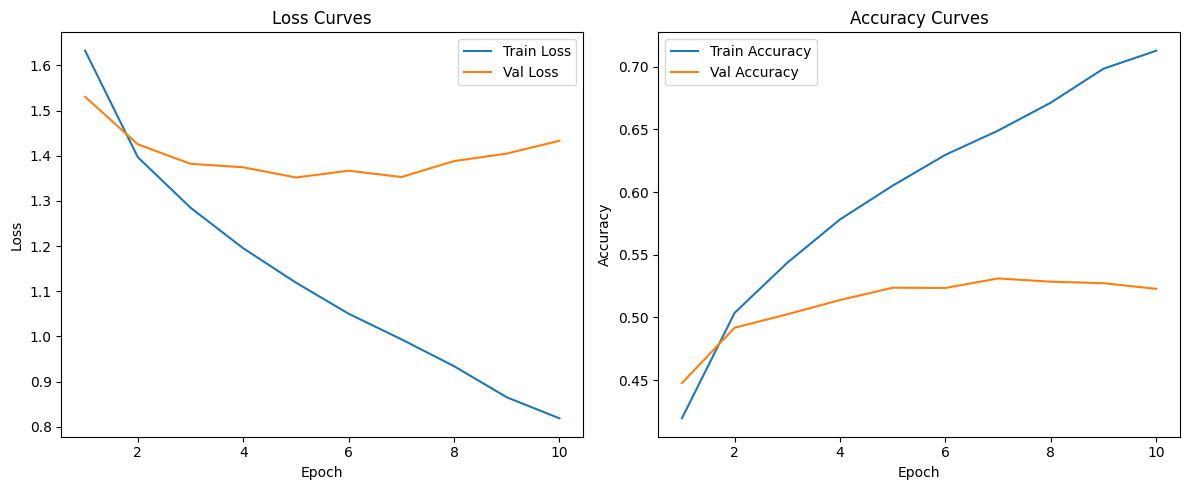

Test Accuracy: 0.5317 (5317/10000)


In [ ]:
if (shouldTrain(UPDATE_MODELS, results_df, 'FC Batch Norm')):
    fc_batch_norm_tl, fc_batch_norm_vl, fc_batch_norm_ta, fc_batch_norm_va, fc_batch_norm_test_acc = fullTrainLoop(fc_batch_norm, 
                        train_loader, val_loader, fc_batch_norm_optimizer, fc_batch_norm_criterion, device, 
                        epochs=BASE_EPOCH, print_results=True, chart=True,
                        stopping_epochs=STOPPING_EPOCH, stopping_threshold=STOPPING_TOL, run_test=True)
    results_df = pd.concat([results_df, pd.DataFrame({'Model': ['FC Batch Norm'], 
                                    'Train Loss': [fc_batch_norm_tl[-1]], 'Val Loss': [fc_batch_norm_vl[-1]], 
                                    'Train Acc': [fc_batch_norm_ta[-1]], 'Val Acc': [fc_batch_norm_va[-1]], 
                                    'Test Acc': [fc_batch_norm_test_acc]})], ignore_index=True)


In [ ]:
results_df.head()

,Model,Train Loss,Val Loss,Train Acc,Val Acc,Test Acc
0,FC Baseline,0.805878,1.499681,0.718675,0.5264,0.5348
1,CNN Baseline,0.325204,0.956565,0.887125,0.7119,0.7135
2,FC Wide,0.639907,1.605606,0.775650,0.5275,0.5274
3,FC Deep,0.845638,1.501356,0.698000,0.5318,0.5344
4,FC Dropout,1.376967,1.394138,0.511825,0.5086,0.5252


### Layer Normalization

Batch normalization works well in many scenarios, but what if we have a model where the batch size is very small, or even just 1? Batch normalization relies on the mean and standard deviation of the values in one batch, so if the batch size becomes very small, those values can become unstable themselves, potentially even making things worse. 

Layer normalization is a technique that normalizes the inputs of each layer across the features, rather than across the batch. This can be more effective in scenarios where the batch size is small, or in certain types of models like recurrent neural networks.

![Layer Normalization](images/layer_norm_example.webp "Layer Normalization" )

#### Just Be Normal!

Normalization is often beneficial, and fairly unlikely to have significant downsides. Layer normalization is less common, more data needs to be collected so it is typically slower. Batch normalization is common, and unless batch sizes are small, tends to perform well. 

![Normalization](images/layer_batch_norm.png "Normalization" )

In [ ]:
fc_layer_norm = nn.Sequential(
    nn.Flatten(),
    nn.Linear( IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS, BASE_HIDDEN),
    nn.LayerNorm(BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.LayerNorm(BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, CLASSES)
)

fc_layer_norm_optimizer = torch.optim.Adam(fc_layer_norm.parameters())
fc_layer_norm_criterion = nn.CrossEntropyLoss()

Epoch 1/10, Train Loss: 1.6648, Val Loss: 1.5689 Train Acc: 0.4093, Val Acc: 0.4408 Stopping Counter: 0/10
Epoch 2/10, Train Loss: 1.4327, Val Loss: 1.4615 Train Acc: 0.4948, Val Acc: 0.4809 Stopping Counter: 0/10
Epoch 3/10, Train Loss: 1.3193, Val Loss: 1.4195 Train Acc: 0.5343, Val Acc: 0.4975 Stopping Counter: 0/10
Epoch 4/10, Train Loss: 1.2299, Val Loss: 1.3912 Train Acc: 0.5666, Val Acc: 0.5005 Stopping Counter: 0/10
Epoch 5/10, Train Loss: 1.1562, Val Loss: 1.3927 Train Acc: 0.5896, Val Acc: 0.5005 Stopping Counter: 1/10
Epoch 6/10, Train Loss: 1.0877, Val Loss: 1.3896 Train Acc: 0.6168, Val Acc: 0.5082 Stopping Counter: 2/10
Epoch 7/10, Train Loss: 1.0226, Val Loss: 1.3865 Train Acc: 0.6417, Val Acc: 0.5174 Stopping Counter: 0/10
Epoch 8/10, Train Loss: 0.9655, Val Loss: 1.3960 Train Acc: 0.6624, Val Acc: 0.5223 Stopping Counter: 0/10
Epoch 9/10, Train Loss: 0.9041, Val Loss: 1.4195 Train Acc: 0.6837, Val Acc: 0.5203 Stopping Counter: 1/10
Epoch 10/10, Train Loss: 0.8431, Val 

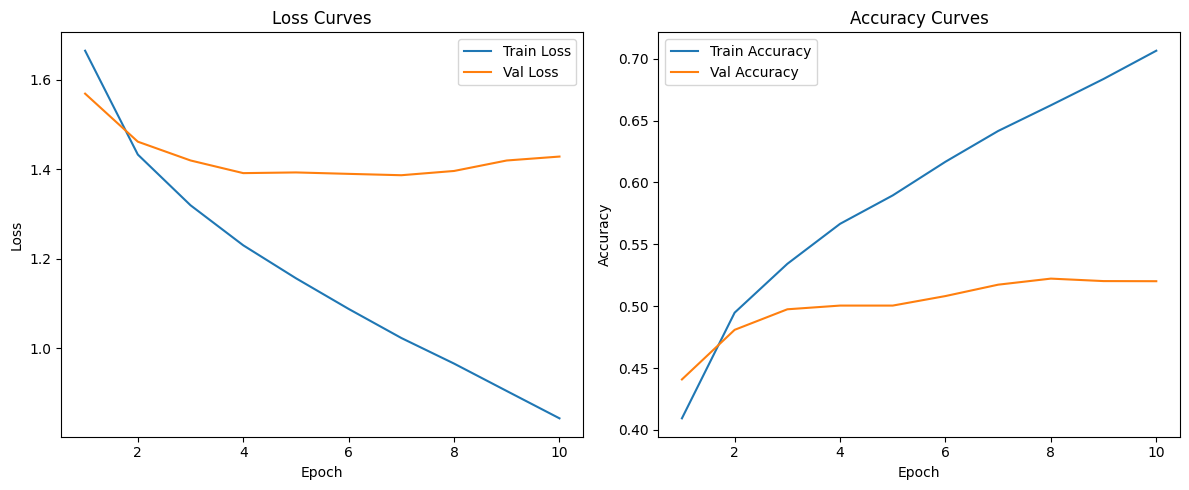

Test Accuracy: 0.5314 (5314/10000)


In [ ]:
if (shouldTrain(UPDATE_MODELS, results_df, 'FC Layer Norm')):
    fc_layer_norm_tl, fc_layer_norm_vl, fc_layer_norm_ta, fc_layer_norm_va, fc_layer_norm_test_acc = fullTrainLoop(fc_layer_norm, 
                        train_loader, val_loader, fc_layer_norm_optimizer, fc_layer_norm_criterion, device, 
                        epochs=BASE_EPOCH, print_results=True, chart=True,
                        stopping_epochs=STOPPING_EPOCH, stopping_threshold=STOPPING_TOL, run_test=True)
    results_df = pd.concat([results_df, pd.DataFrame({'Model': ['FC Layer Norm'], 
                                    'Train Loss': [fc_layer_norm_tl[-1]], 'Val Loss': [fc_layer_norm_vl[-1]], 
                                    'Train Acc': [fc_layer_norm_ta[-1]], 'Val Acc': [fc_layer_norm_va[-1]], 
                                    'Test Acc': [fc_layer_norm_test_acc]})], ignore_index=True)

## Activation 

Activation functions are the key to adding non-linearity to the network allowing it to learn complex and non-linear relationships in the data. We've used ReLU as the default and that is a solid choice in most cases. ReLU has one issue, the dying ReLU problem. This can happen when we get inputs to the activation function fall in the negative area. In short there can be neurons that "die" and never get updated again because the value becomes 0 and stays 0. These dead neurons are a problem as they now aren't contributing to the learning.

![ReLU](images/relu.jpeg "ReLU")

To combat the dying ReLU problem there are a couple of other activation functions that avoid that issue - Leaky ReLU and ELU. Each one changes the negative values to something other than 0 - Leaky ReLU uses a slight linear gradient, ELU uses an exponential function for a similar, but curved, slight gradient. These ReLU variants are a good choice, and probably the 'best' overall activation functions for most scenarios. One some datasets will be impacted by the dying ReLU problem. 

These activation function also have an impact on the speed of training. The ReLU function is very fast to calculate, and the Leaky ReLU and ELU functions are a bit slower. Other activation functions may be even more expensive. Will this matter? As with many things, it depends. For the small examples we are using, it probably won't matter much. On very large applications, we may need to consider the ability to train models more quickly, and try more models vs. the improved fit of another activation function.

#### Activation Function Guidelines

We can write a few rules of thumb to guide us in deciding on activation functions. On the whole, the choice is like a hyperparameter choice, and we want to choose whichever is the best for our data. Some of the guidelines are:
<ul>
<li> The output layer should have an activation function that matches the type of problem we are solving. 
    <ul>
    <li> <b>Regression:</b> Linear activation function.
    <li> <b>Binary Classification:</b> Sigmoid activation function.
    <li> <b>Multiclass Classification:</b> Softmax activation function.
    </ul>
<li> Depending on the type of network/problem, our hidden layers default to different activation functions:
    <ul>
    <li> <b>Deep Neural Networks:</b> ReLU activation functions.
    <li> <b>Convolutional Neural Networks: (Images)</b> ReLU activation functions.
    <li> <b>Recurrent Neural Networks:(Seqential, Time Series)</b> Tanh activation function.
    </ul>
</ul>

There are more activation functions, and others are being developed somewhat regularly. If in doubt, just use a ReLU variant. 

#### Sample Activation Change

For this sample, we can swap the activation function to tanh. This is commonly used in recurrent neural networks, but not very often with other types. I would expect this model to perform worse than ReLU, but it is hard to predict specifically. 

In [ ]:
fc_tanh = nn.Sequential(
    nn.Flatten(),
    nn.Linear( IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS, BASE_HIDDEN),
    nn.Tanh(),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.Tanh(),
    nn.Linear(BASE_HIDDEN, CLASSES)
)
fc_tanh_optimizer = torch.optim.Adam(fc_tanh.parameters())
fc_tanh_criterion = nn.CrossEntropyLoss()

Epoch 1/10, Train Loss: 1.7720, Val Loss: 1.7394 Train Acc: 0.3797, Val Acc: 0.3861 Stopping Counter: 0/10
Epoch 2/10, Train Loss: 1.5916, Val Loss: 1.6406 Train Acc: 0.4486, Val Acc: 0.4274 Stopping Counter: 0/10
Epoch 3/10, Train Loss: 1.5007, Val Loss: 1.6006 Train Acc: 0.4824, Val Acc: 0.4467 Stopping Counter: 0/10
Epoch 4/10, Train Loss: 1.4209, Val Loss: 1.5941 Train Acc: 0.5079, Val Acc: 0.4549 Stopping Counter: 0/10
Epoch 5/10, Train Loss: 1.3531, Val Loss: 1.5666 Train Acc: 0.5329, Val Acc: 0.4582 Stopping Counter: 0/10
Epoch 6/10, Train Loss: 1.2869, Val Loss: 1.5775 Train Acc: 0.5575, Val Acc: 0.4581 Stopping Counter: 1/10
Epoch 7/10, Train Loss: 1.2234, Val Loss: 1.5988 Train Acc: 0.5782, Val Acc: 0.4686 Stopping Counter: 2/10
Epoch 8/10, Train Loss: 1.1623, Val Loss: 1.6135 Train Acc: 0.5999, Val Acc: 0.4599 Stopping Counter: 0/10
Epoch 9/10, Train Loss: 1.1007, Val Loss: 1.6331 Train Acc: 0.6214, Val Acc: 0.4641 Stopping Counter: 1/10
Epoch 10/10, Train Loss: 1.0346, Val 

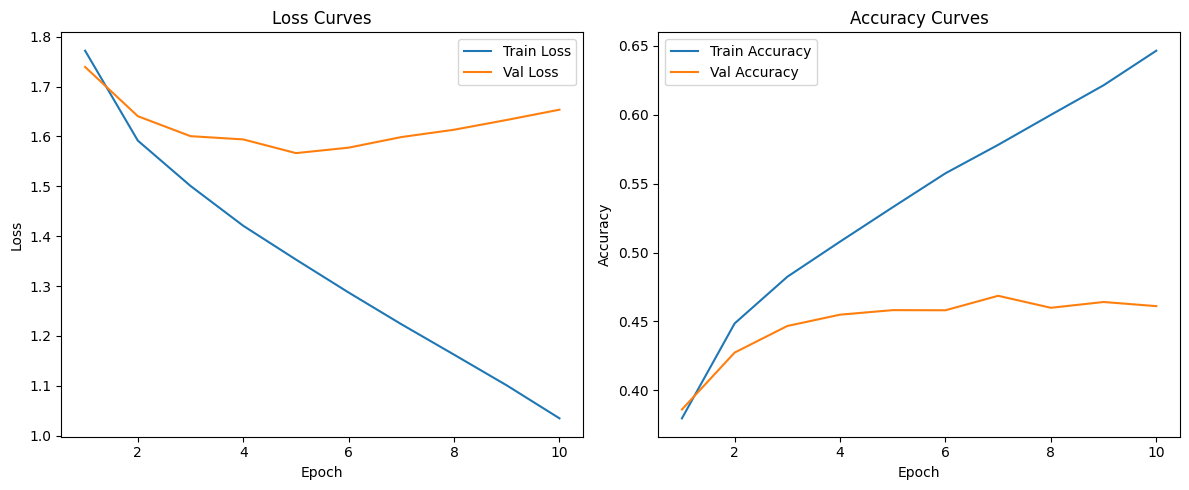

Test Accuracy: 0.4686 (4686/10000)


In [ ]:
if (shouldTrain(UPDATE_MODELS, results_df, 'FC Tanh')):
    fc_tanh_tl, fc_tanh_vl, fc_tanh_ta, fc_tanh_va, fc_tanh_test_acc = fullTrainLoop(fc_tanh, train_loader, val_loader, fc_tanh_optimizer,
                    fc_tanh_criterion, device, epochs=BASE_EPOCH, print_results=True, chart=True,
                    stopping_epochs=STOPPING_EPOCH, stopping_threshold=STOPPING_TOL, run_test=True)
    results_df = pd.concat([results_df, pd.DataFrame({'Model': ['FC Tanh'], 
                                'Train Loss': [fc_tanh_tl[-1]], 'Val Loss': [fc_tanh_vl[-1]], 
                                'Train Acc': [fc_tanh_ta[-1]], 'Val Acc': [fc_tanh_va[-1]], 
                                'Test Acc': [fc_tanh_test_acc]})], ignore_index=True)

In [ ]:
results_df.head()

,Model,Train Loss,Val Loss,Train Acc,Val Acc,Test Acc
0,FC Baseline,0.805878,1.499681,0.718675,0.5264,0.5348
1,CNN Baseline,0.325204,0.956565,0.887125,0.7119,0.7135
2,FC Wide,0.639907,1.605606,0.775650,0.5275,0.5274
3,FC Deep,0.845638,1.501356,0.698000,0.5318,0.5344
4,FC Dropout,1.376967,1.394138,0.511825,0.5086,0.5252


### CNN With Several Changes

In [ ]:
cnn_final = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, KERNEL_NUM, KERNEL_SIZE, STRIDE, PADDING),
    nn.BatchNorm2d(KERNEL_NUM),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Dropout(0.25),
    nn.Conv2d(KERNEL_NUM, KERNEL_NUM * 2, KERNEL_SIZE, STRIDE, PADDING),
    nn.BatchNorm2d(KERNEL_NUM * 2),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Dropout(0.25),
    nn.Flatten(),
    nn.Linear(FLAT_DIM, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, BASE_HIDDEN),
    nn.ReLU(),
    nn.Linear(BASE_HIDDEN, CLASSES)
)
cnn_fin_optimizer = torch.optim.Adam(cnn_final.parameters(), weight_decay=BASE_WEIGHT_DECAY)
cnn_fin_criterion = nn.CrossEntropyLoss()

In [ ]:
if (shouldTrain(UPDATE_MODELS, results_df, 'CNN Final')):
    cnn_fin_tl, cnn_fin_vl, cnn_fin_ta, cnn_fin_va, cnn_fin_test_acc = fullTrainLoop(cnn_final, train_loader, 
                        val_loader, cnn_fin_optimizer, cnn_fin_criterion, device, 
                        epochs=BASE_EPOCH, print_results=True, chart=True,
                        stopping_epochs=STOPPING_EPOCH, stopping_threshold=STOPPING_TOL, run_test=True)
    results_df = pd.concat([results_df, pd.DataFrame({'Model': ['CNN Final'], 
                                    'Train Loss': [cnn_fin_tl[-1]], 'Val Loss': [cnn_fin_vl[-1]], 
                                    'Train Acc': [cnn_fin_ta[-1]], 'Val Acc': [cnn_fin_va[-1]], 
                                    'Test Acc': [cnn_fin_test_acc]})], ignore_index=True)


Epoch 1/10, Train Loss: 1.4933, Val Loss: 1.2400 Train Acc: 0.4564, Val Acc: 0.5509 Stopping Counter: 0/10
Epoch 2/10, Train Loss: 1.1183, Val Loss: 0.9930 Train Acc: 0.5983, Val Acc: 0.6431 Stopping Counter: 0/10
Epoch 3/10, Train Loss: 0.9926, Val Loss: 0.9255 Train Acc: 0.6444, Val Acc: 0.6684 Stopping Counter: 0/10
Epoch 4/10, Train Loss: 0.9052, Val Loss: 0.9184 Train Acc: 0.6789, Val Acc: 0.6740 Stopping Counter: 0/10
Epoch 5/10, Train Loss: 0.8435, Val Loss: 0.8919 Train Acc: 0.7013, Val Acc: 0.6879 Stopping Counter: 0/10


In [ ]:
results_df.head()

,Model,Train Loss,Val Loss,Train Acc,Val Acc,Test Acc
0,FC Baseline,0.805798,1.495059,0.720475,0.5245,0.5266
1,CNN Baseline,0.357379,0.939441,0.878050,0.7092,0.7093
2,FC Wide,0.647939,1.594054,0.770900,0.5257,0.5341
3,FC Deep,0.831835,1.476860,0.703650,0.5302,0.5335
4,FC Dropout,1.374447,1.384095,0.512775,0.5144,0.5209


## Results

Here's our results! Note that for this example here I didn't really spend time selecting and tuning the details, I just made a demonstration of each. In the real world, I'd need to take what looks promising and tune it further. 

There are patterns in the performance of the different models, and this ties back to the idea of neural networks being universal function approximators. Each of these models can theoretically learn the relationships in the data to the same degree, but they aren't all equally suited to do so. 

In each case, we aren't hitting the theoretical maximum performance of the model since we don't have that much data or time. All of the dense networks tended to converge on a similar level of accuracy, even though each is different in the structure and/or tuning. The CNN models showed a similar pattern, but with a higher baseline, since they are better suited to the data and can learn more effectively from it. We can get the performance of the CNN up if we tune it, but the biggest jump came just from using a model that fits the data. This is similar to the idea of a parabola and a linear regression in 2D - the model doesn't fit the data well, so no matter what we tweak, we're starting at a disadvantage vs a model that fits the data well.

### Test and Validation

As a side note, we can see the results of validation and testing for each model. We sometimes just use two datasets, training and validation, and report the validation performance as the final performance of the model. This isn't technically 'proper', but in low consequence scenarios it is fine. 

In [ ]:
results_df["percent_worse_than_best"] = (results_df['Val Acc'].max() - results_df['Val Acc']) / results_df['Val Acc'].max() * 100
results_df = results_df.apply(np.round, decimals=2)
results_df.sort_values(by='Val Acc', ascending=False)

,Model,Train Loss,Val Loss,Train Acc,Val Acc,Test Acc,percent_worse_than_best
9,CNN Final,0.65,0.80,0.77,0.73,0.73,0.00
1,CNN Baseline,0.36,0.94,0.88,0.71,0.71,2.65
0,FC Baseline,0.81,1.50,0.72,0.52,0.53,27.72
2,FC Wide,0.65,1.59,0.77,0.53,0.53,26.70
5,FC L2 Reg,0.81,1.48,0.72,0.53,0.53,26.70
3,FC Deep,0.83,1.48,0.70,0.53,0.53,26.78
7,FC Layer Norm,0.84,1.41,0.70,0.53,0.53,26.61
6,FC Batch Norm,0.82,1.43,0.71,0.52,0.53,27.77
4,FC Dropout,1.37,1.38,0.51,0.51,0.52,28.51
8,FC Tanh,1.03,1.63,0.65,0.47,0.47,35.41


In [ ]:
sns.barplot(x='Model', y='Val Acc', data=results_df.sort_values(by='Val Acc', ascending=False))
plt.xticks(rotation=45)
plt.title('Validation Accuracy by Model')
plt.ylabel('Validation Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## So What Do We Do?

As you can probably guess, the ultimate answer is to test and see what works. There's also a tendency for several variations of models to perform similarly given enough training. As well, each tuning change will impact others, so we can't simply isolate each change. 

There are some general rules that we can follow to help guide us:
<ul>
<li> Start with a simple baseline model (of whatever architechture makes sense), size it to be 'big enough' that overfitting is possible. </li>
<li> Train the model and look at the training and validation loss curves. </li>
<li> If the training loss is decreasing at the end, increase the number of epochs. </li>
<li> Use tips like the ones below to adjust further. </li>
</ul>

### Common Patterns and Solutions

#### Training Loss Decreases, Validation Loss Doesn't

This is a common pattern that indicates there's likely overfitting happening. The model is learning to predict the training data better and better, but it's not improving on the validation data, which suggests that it's learning patterns that are specific to the training data and not generalizing well to new data.

To address this, we can try several things:
<ul>
<li> Reduce the capacity of the model (fewer layers, fewer neurons). </li>
<li> Increase regularization (higher weight decay, more dropout). </li>
<li> Use early stopping to prevent the model from training too long. </li>
</ul>

<b>Note:</b> This is a pretty good starting point for more tuning. 

#### Training Loss and Validation Loss Very Similar

If the training loss and validation loss are nearly identical throughout training, or the validation loss is lower, this can indicate that the model is underfitting. The model isn't learning enough from the training data, so little that it can't ever perform better on the data it was trained on than the validation data. 

To address this, we can try several things:
<ul>
<li> Increase the capacity of the model (more layers, more neurons). </li>
<li> Decrease regularization (lower weight decay, less dropout). </li>
<li> Train for more epochs. </li>
</ul>

#### Loss Chart is Unstable

If the loss chart is very unstable, with the loss jumping around a lot from epoch to epoch, this can indicate a few different things:
<ul>
<li> The learning rate may be too high, causing the model to take large steps in the parameter space, which can lead to erratic behavior. </li>
<li> The model may be too complex for the amount of data, leading to overfitting and instability. </li>
<li> There may be issues with the data, such as outliers or noise, that are causing the model to struggle to learn. </li>
<li> Data sets are small. </li>
</ul>

To address this, we can try several things:
<ul>
<li> Reduce the learning rate to allow the model to take smaller steps and find a more stable path to the minimum. </li>
<li> Reduce the capacity of the model to prevent it from overfitting and becoming unstable. </li>
<li> Clean the data to remove outliers or reduce noise, which can help the model learn more effectively. </li>
</ul>

I'd try turning down the learning rate first and see if that works. If the model is still learning, i.e. the loss is getting lower, but it is very unstable, we may be able to correct it with this simple change. If the model is just bouncing around and not learning at all, then we may need to look at the data or the model architecture.

#### Performance Plateaus

If there are seemingly arbitrary points in loss/accuracy that the model can't get past, this may indicate that the model is a poor fit (unable to shape itself to the data), or that the learning rate is too low and the model is stuck in a local minimum.

To address this, we can try several things:
<ul>
<li> Increase the capacity of the model to allow it to learn more complex relationships. </li>
<li> Change something in the architecture to allow the model to learn different relationships. </li>
<li> Increase the learning rate to help the model escape local minima. </li>
</ul>

## Exercise #1 - Tensorboard This

As an exercise, add tensorboard monitoring to the examples above, so we can monitor the training and validation loss and accuracy in real time.

## Exercise #2

Make a model for this data. As you do, try some different variations on both the model's architecture and the other tuning options. Some things specifically that you should get some practice with are:

<ul>
<li> Adjusting the number of layers and neurons, wide models and deep ones. </li>
<li> Adjusting the regularization with weight decay and dropout. </li>
<li> Using other types of layers like batch normalization and layer normalization. </li>
</ul>

In [ ]:
from torchvision.datasets import KMNIST

kmnist_train = KMNIST(root='./kmnist_data', train=True, download=True, transform=transform)
kmnist_test = KMNIST(root='./kmnist_data', train=False, download=True, transform=transform)

ktrain_loader = DataLoader(kmnist_train, batch_size=BASE_BATCH, shuffle=True)
kval_loader = DataLoader(kmnist_train, batch_size=BASE_BATCH, shuffle=False)

## Optimization and Batches

### Optimizer

The optimizer is the algorithm that we use to update the model's parameters during training, a.k.a. it 'does' the gradient descent process. In theory, any process should get you to the same solution, but in practice, having the process be efficient and converge quickly is critical. We are often limited by time and resources, so finding a solution more quickly allows for more trials and more tuning.

We have been using the Adam optimizer, which is the most common default. It tends to work well in a wide variety of scenarios and we can safely rely on it to do the job. However, there are other optimizers that may work better in certain scenarios, so it may be worth some experimentation, especially if you're going to be training a large model that will take a long time. 

Some optimizers are smart, and will adjust the learning rate during training, which can lead to faster convergence and better performance. Several are able to maintain a separate learning rate for each parameter, which can also help with convergence in complex models.

![Optimizers](images/optimizers.gif "Optimizers")

#### Adam Optimizer 

Adam is an optimization algorithm that combines the benefits of two other popular optimizers: AdaGrad and RMSProp. It computes adaptive learning rates for each parameter, which can lead to faster convergence and better performance on a wide range of problems. Adam is particularly effective for training deep neural networks and is widely used in the machine learning community.

#### Adam Competitors

There are several other optimizers that are commonly used in deep learning, including:
<ul>
<li>SGD (Stochastic Gradient Descent): A simple and widely used optimizer that updates parameters based on the gradient of the loss function with respect to the parameters. It can be effective but may require careful tuning of the learning rate.</li>
<li>RMSProp: An optimizer that divides the learning rate by an exponentially decaying average of squared gradients. It is particularly effective for training recurrent neural networks.</li>
<li>AdaGrad: An optimizer that adapts the learning rate for each parameter based on the historical gradients. It can be effective for sparse data but may lead to a rapidly decreasing learning rate.</li>
<li>AdamW: A variant of Adam that decouples weight decay from the gradient updates, which can lead to better generalization performance.</li>
</ul>

For selecting an optimizer, it's often a good idea to start with Adam and then move to an alternative if the model isn't learning effectively. Basing your choice on similar problems is the easiest way to get a good starting point - the specifics of which algorithm will find the bottom of a several thousand dimension loss curve are hard to predict ahead of time. 

<b>Note:</b> The choice of optimizer can have a significant impact on the training process, but it isn't something we'll focus much on. 

### Learning Rate

For any optimizer, the primary hyperparameter to tune is the learning rate, which controls how much the model's parameters are updated during training. 

As a rough guideline, we can adjust our learning rate up or down based on:
<ul>
<li>Increase the learning rate if:</li>
    <ul>
    <li>The training loss is decreasing very slowly, or seems stuck.</li>
    <li>The model is hitting epoch limits without convergance.</li>
    </ul>
<li>Decrease the learning rate if:</li>
    <ul>
    <li>The training loss is very noisy.</li>
    <li>Losses improve, then get worse, then improve again repeatedly, without clear 'jumps' of progress.</li>
    <li>The model is diverging, with losses getting worse over time.</li>
    </ul>
</ul>

These adjustments are impacted by basically all the other factors of fitting a model, so what works from time to time will vary quite a bit. In practice, this parameter is a starting point for the optimizer, and many optimizers will adjust the learning rate during training. However, setting a good initial learning rate can help the model converge faster and achieve better performance.

#### Stick to Schedule

Our learning rate control is going to be pretty simple, we will bump the learning rate up or down, usually by a factor of 10, and try again. In more sophisticated applications, we are also able to manage what we call the learning rate schedule, which is how the learning rate changes during training. For example, we can start with a higher learning rate and then decrease it over time, which can help the model converge more effectively.

By default, we'll ignore this and stick to the simple approach. Adam and similar optimizers will adjust the learning rate during training, so we can rely on that. 

### Batch Size

Another factor that works with the optimizer is the batch size. The batch size is the number of samples that are processed together in one forward and backward pass during training. It can have a significant impact on the training process and the performance of the model.

#### How Stochastic are You?

The batch size controls how "stochastic" the training process is, we can effectively scale if we are going to update the model's parameters after every single sample, or only once per epoch. 

![Batch Sizes](images/iterations_epoch.webp "Batch Sizes")

#### GPU Capacity

With neural networks, we have some new concerns that didn't really come up with regression - the GPU capacity. The ultimate limit on batch size is the amount of GPU memory available, we need to be able to fit whatever the model has, along with a batch of data, and the intermediate results of the forward and backward passes into the GPU memory or we'll get an error and things will fail. Other concerns are always overridden by this one, so if we're doing something with larger images or similar, we may have it largely dictated to us. 

#### Time Performance

Another consideration is the performance of the model with respect to training time. Large models can train for weeks, on tens of thousands of GPUs, so small time improvements can save millions of dollars. In general, the most time efficient batch size is whatever can saturate the memory of the GPU; there are per-batch fixed overhead, so we want to make sure that we're doing as much work as possible in each batch to maximize the efficiency. In some cases, this may be a very important consideration. 

With smaller batches, the model's parameters are updated more frequently, which can lead to faster convergence and better generalization. You need to go through fewer epochs, so less total processing may be needed. However, smaller batches can also lead to noisier updates, since each update is only based on a few samples. 

### So What Do I Do?

There isn't a definitive answer to this question, and things are pretty situation dependent. Current best practices suggest to lean towards a smaller batch size and a lower learning rate for best overall performance. If things are taking a long time, try cranking up the batch size and see if performance is still good. If your training is taking a long time, a larger batch size may be worth the trade-off for speed, and therefore the opportunity to run more trials. 

<b>Note:</b> Lots of the examples have a large batch size, this is for speed because they get trained frequently. If we wanted maximal performance for a real model, we'd probably lower them. 